In [1]:
import pandas as pd
import glob

In [2]:
import plotly.io as pio
pio.renderers

Renderers configuration
-----------------------
    Default renderer: 'vscode'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

In [3]:
pio.renderers.default = "notebook_connected"

In [4]:


# Verzeichnis der CSV-Dateien (z. B. falls sie alle in einem Ordner gespeichert sind)
csv_files = glob.glob('data/*.csv')

# Liste, um alle DataFrames zu speichern
dataframes = []

rename_columns = {
    'STRZUSTAND': 'USTRZUSTAND',
    # weitere Spalten
}

# Lade jede CSV-Datei, konvertiere die Spalten und füge den DataFrame der Liste hinzu
for file in csv_files:
    df = pd.read_csv(file, delimiter=';')
    # Konvertiere die Koordinaten in float
    df['XGCSWGS84'] = df['XGCSWGS84'].str.replace(',', '.').astype(float)
    df['YGCSWGS84'] = df['YGCSWGS84'].str.replace(',', '.').astype(float)
    df = df.rename(columns={col: new_col for col, new_col in rename_columns.items() if col in df.columns})
    dataframes.append(df)

# Verbinde alle DataFrames in einen großen DataFrame
unfaelle = pd.concat(dataframes, ignore_index=True)

# Überprüfe die ersten Zeilen des kombinierten DataFrames
unfaelle.head()


,OBJECTID,ULAND,UREGBEZ,UKREIS,UGEMEINDE,UJAHR,UMONAT,USTUNDE,UWOCHENTAG,UKATEGORIE,...,IstFuss,IstKrad,IstGkfz,IstSonstige,LINREFX,LINREFY,XGCSWGS84,YGCSWGS84,USTRZUSTAND,UIDENTSTLAE
0,95521,5,3,15,0,2019,1,5,3,3,...,0,0,0,0,"355698,9316","5645896,103",6.945805,50.946603,1,NaN
1,95703,5,3,15,0,2019,1,4,3,2,...,0,0,0,0,"364105,2885","5643403,273",7.066328,50.926241,1,NaN
2,95717,5,3,15,0,2019,1,19,3,3,...,0,0,0,0,"356960,2754","5634849,847",6.968075,50.847644,1,NaN
3,96051,5,3,15,0,2019,1,14,1,2,...,0,0,0,0,"358260,0353","5644558,441",6.982760,50.935217,1,NaN
4,96074,5,3,15,0,2019,1,19,7,3,...,0,0,0,0,"364366,245","5641545,028",7.070730,50.909602,1,NaN


In [5]:
unfaelle.shape

(12497, 25)

In [6]:
#save the data
unfaelle.to_csv('unfaelle.csv', index=False)


In [7]:
# Store accident types in a dictionary
accident_types = {
    1: "Zusammenstoß mit anfahrendem/ anhaltendem/ruhendem Fahrzeug",
    2: "Zusammenstoß mit vorausfahrendem / wartendem Fahrzeug",
    3: "Zusammenstoß mit seitlich in gleicher Richtung fahrendem Fahrzeug",
    4: "Zusammenstoß mit entgegenkommendem Fahrzeug",
    5: "Zusammenstoß mit einbiegendem / kreuzendem Fahrzeug",
    6: "Zusammenstoß zwischen Fahrzeug und Fußgänger",
    7: "Aufprall auf Fahrbahnhindernis",
    8: "Abkommen von Fahrbahn nach rechts",
    9: "Abkommen von Fahrbahn nach links",
    0: "Unfall anderer Art"
}

# Retrieve accident type by index
def get_accident_type(index):
    return accident_types.get(index, "Unknown accident type")

# copy the data
unfaelle_edit = unfaelle.copy()
unfaelle_edit['UART'] = unfaelle_edit['UART'].map(accident_types)

In [8]:
months = {
    1: "Januar",
    2: "Februar",
    3: "März",
    4: "April",
    5: "Mai",
    6: "Juni",
    7: "Juli",
    8: "August",
    9: "September",
    10: "Oktober",
    11: "November",
    12: "Dezember"
}
unfaelle_edit['UMONAT'] = unfaelle_edit['UMONAT'].map(months)

In [9]:
weekday = {
    1: "Montag",
    2: "Dienstag",
    3: "Mittwoch",
    4: "Donnerstag",
    5: "Freitag",
    6: "Samstag",
    7: "Sonntag"
}
unfaelle_edit['UWOCHENTAG'] = unfaelle_edit['UWOCHENTAG'].map(weekday)

In [10]:
category = {
    1: "Unfall mit Getöteten",
    2: "Unfall mit Schwerverletzten",
    3: "Unfall mit Leichtverletzten",
}
unfaelle_edit['UKATEGORIE'] = unfaelle_edit['UKATEGORIE'].map(category)

In [11]:
light = {
    0: "Tageslicht",
    1: "Dämmerung",
    2: "Dunkelheit"
}
unfaelle_edit['ULICHTVERH'] = unfaelle_edit['ULICHTVERH'].map(light)

In [12]:
condition = {
    0: "trocken",
    1: "nass/feucht",
    2: "winterglatt",
}
unfaelle_edit['USTRZUSTAND'] = unfaelle_edit['USTRZUSTAND'].map(condition)


In [13]:
# make new column with a string comma seperated of the participants in the accident if IstRad is Rad is 1 add Rad to the string in this column for the row
unfaelle_edit['Participants'] = unfaelle_edit['IstRad'].apply(lambda x: 'Rad, ' if x == 1 else "")
unfaelle_edit['Participants'] = unfaelle_edit['Participants'] + unfaelle_edit['IstFuss'].apply(lambda x: 'Fuss, ' if x == 1 else "")
unfaelle_edit['Participants'] = unfaelle_edit['Participants'] + unfaelle_edit['IstKrad'].apply(lambda x: 'Krad, ' if x == 1 else "")
unfaelle_edit['Participants'] = unfaelle_edit['Participants'] + unfaelle_edit['IstPKW'].apply(lambda x: 'PKW, ' if x == 1 else "")
unfaelle_edit['Participants'] = unfaelle_edit['Participants'] + unfaelle_edit['IstGkfz'].apply(lambda x: 'Gkfz, ' if x == 1 else "")
unfaelle_edit['Participants'] = unfaelle_edit['Participants'] + unfaelle_edit['IstSonstige'].apply(lambda x: 'Sonstige' if x == 1 else "")

#remove the last comma
unfaelle_edit['Participants'] = unfaelle_edit['Participants'].str.rstrip(', ')

unfaelle_edit['Participants']

0                  PKW
1                  PKW
2                  PKW
3                  PKW
4                  PKW
             ...      
12492    PKW, Sonstige
12493              PKW
12494              PKW
12495    PKW, Sonstige
12496    PKW, Sonstige
Name: Participants, Length: 12497, dtype: object

In [14]:
type = {
    1: "Fahrunfall",
    2: "Abbiegeunfall",
    3: "Einbiegen / Kreuzen-Unfall",
    4: "Überschreiten-Unfall",
    5: "Unfall durch ruhenden Verkehr",
    6: "Unfall im Längsverkehr",
    7: "Sonstiger Unfall"
}
unfaelle_edit['UTYP1'] = unfaelle_edit['UTYP1'].map(type)

In [15]:
unfaelle_edit.head()

,OBJECTID,ULAND,UREGBEZ,UKREIS,UGEMEINDE,UJAHR,UMONAT,USTUNDE,UWOCHENTAG,UKATEGORIE,...,IstKrad,IstGkfz,IstSonstige,LINREFX,LINREFY,XGCSWGS84,YGCSWGS84,USTRZUSTAND,UIDENTSTLAE,Participants
0,95521,5,3,15,0,2019,Januar,5,Mittwoch,Unfall mit Leichtverletzten,...,0,0,0,"355698,9316","5645896,103",6.945805,50.946603,nass/feucht,NaN,PKW
1,95703,5,3,15,0,2019,Januar,4,Mittwoch,Unfall mit Schwerverletzten,...,0,0,0,"364105,2885","5643403,273",7.066328,50.926241,nass/feucht,NaN,PKW
2,95717,5,3,15,0,2019,Januar,19,Mittwoch,Unfall mit Leichtverletzten,...,0,0,0,"356960,2754","5634849,847",6.968075,50.847644,nass/feucht,NaN,PKW
3,96051,5,3,15,0,2019,Januar,14,Montag,Unfall mit Schwerverletzten,...,0,0,0,"358260,0353","5644558,441",6.982760,50.935217,nass/feucht,NaN,PKW
4,96074,5,3,15,0,2019,Januar,19,Sonntag,Unfall mit Leichtverletzten,...,0,0,0,"364366,245","5641545,028",7.070730,50.909602,nass/feucht,NaN,PKW


In [16]:
#get rid of outlier coordinates
unfaelle_edit = unfaelle_edit[(unfaelle_edit['XGCSWGS84'] < 7.16) & (unfaelle_edit['YGCSWGS84'] > 50.825)]

In [17]:
unfaelle_cut = unfaelle_edit[['XGCSWGS84', 'YGCSWGS84','UJAHR', 'UMONAT', 'UWOCHENTAG','USTUNDE', 'UART', 'UKATEGORIE', 'UTYP1', 'ULICHTVERH', 'USTRZUSTAND', 'Participants']]
unfaelle_cut.head(20)

,XGCSWGS84,YGCSWGS84,UJAHR,UMONAT,UWOCHENTAG,USTUNDE,UART,UKATEGORIE,UTYP1,ULICHTVERH,USTRZUSTAND,Participants
0,6.945805,50.946603,2019,Januar,Mittwoch,5,Zusammenstoß mit seitlich in gleicher Richtung...,Unfall mit Leichtverletzten,Sonstiger Unfall,Dunkelheit,nass/feucht,PKW
1,7.066328,50.926241,2019,Januar,Mittwoch,4,Abkommen von Fahrbahn nach links,Unfall mit Schwerverletzten,Sonstiger Unfall,Dunkelheit,nass/feucht,PKW
2,6.968075,50.847644,2019,Januar,Mittwoch,19,Zusammenstoß mit vorausfahrendem / wartendem F...,Unfall mit Leichtverletzten,Unfall im Längsverkehr,Dunkelheit,nass/feucht,PKW
3,6.982760,50.935217,2019,Januar,Montag,14,Abkommen von Fahrbahn nach rechts,Unfall mit Schwerverletzten,Fahrunfall,Tageslicht,nass/feucht,PKW
4,7.070730,50.909602,2019,Januar,Sonntag,19,Zusammenstoß mit vorausfahrendem / wartendem F...,Unfall mit Leichtverletzten,Unfall im Längsverkehr,Dunkelheit,nass/feucht,PKW
5,7.034250,50.967339,2019,Januar,Sonntag,22,Zusammenstoß mit einbiegendem / kreuzendem Fah...,Unfall mit Leichtverletzten,Einbiegen / Kreuzen-Unfall,Dunkelheit,nass/feucht,PKW
6,7.011452,50.957321,2019,Januar,Sonntag,17,Zusammenstoß zwischen Fahrzeug und Fußgänger,Unfall mit Leichtverletzten,Abbiegeunfall,Dunkelheit,nass/feucht,"Fuss, PKW"
7,7.014616,51.006059,2019,Januar,Sonntag,15,Abkommen von Fahrbahn nach rechts,Unfall mit Schwerverletzten,Sonstiger Unfall,Tageslicht,nass/feucht,PKW
8,6.831871,51.064807,2019,Januar,Sonntag,18,Abkommen von Fahrbahn nach links,Unfall mit Leichtverletzten,Fahrunfall,Dunkelheit,nass/feucht,PKW
9,7.075932,50.898045,2019,Januar,Samstag,11,Zusammenstoß zwischen Fahrzeug und Fußgänger,Unfall mit Leichtverletzten,Sonstiger Unfall,Tageslicht,nass/feucht,"Fuss, PKW"


In [18]:
labels = {
    "OBJECTID": "Objekt ID",
    "UJAHR": "Unfall Jahr",
    "UMONAT": "Unfall Monat",
    "UWOCHENTAG": "Wochentag",
    "USTUNDE": "Stunde",
    "UKATEGORIE": "Unfallkategorie",
    "ULICHTVERH": "Lichtverhältnisse",
    "STRZUSTAND": "Straßenzustand",
    "Participants": "Teilnehmer"
}

import plotly.express as px
#plot only category 1 and 2
#unfaelle_edit = unfaelle_edit[unfaelle_edit['UKATEGORIE'].isin(['Unfall mit Getöteten'])]

fig = px.scatter_map(unfaelle_edit, lat="YGCSWGS84", lon="XGCSWGS84", hover_name="UART", hover_data=["OBJECTID","UJAHR","UMONAT",
                                                                                                     "UWOCHENTAG","USTUNDE", "UKATEGORIE", "UTYP1", "ULICHTVERH", "USTRZUSTAND", "Participants"],
                        color_discrete_sequence=["red"], zoom=9, height=300, labels=labels)
fig.update_layout(map_style="open-street-map")

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [19]:
unfaelle_months = unfaelle_edit['UMONAT'].value_counts().sort_index()
#sort after month
unfaelle_months['UMONAT'] = pd.Categorical(unfaelle_edit['UMONAT'], categories=months.values(), ordered=True)

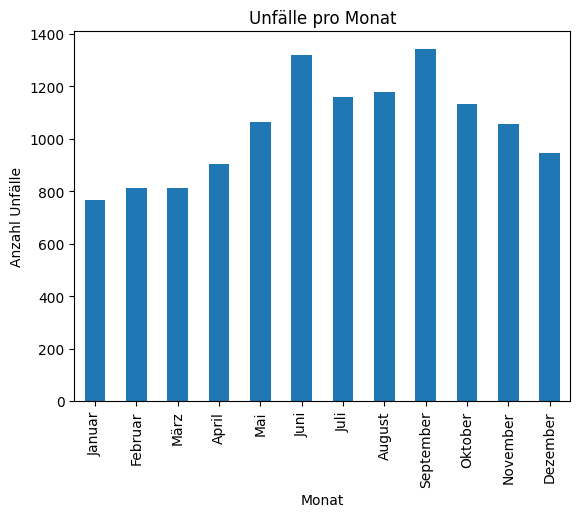

In [20]:
#plot the number of accidents per month with a bar chart in matplotlib sortiert nach monaten
import matplotlib.pyplot as plt
unfaelle_months['UMONAT'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Monat')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Monat')
plt.show()


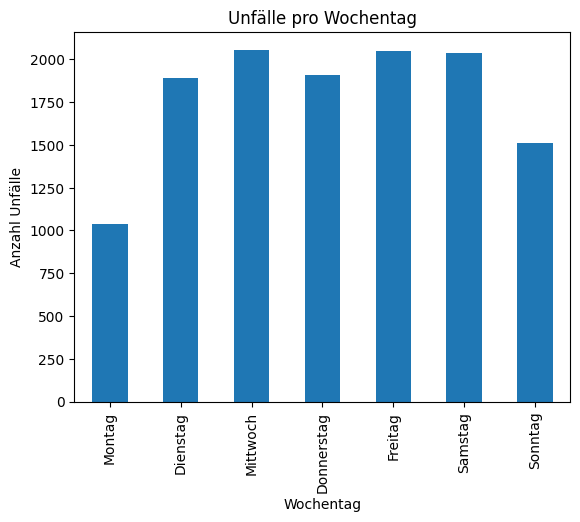

In [21]:
#plot the number of accidents by the day of the week sorted by the day of the week
unfaelle_weekday = unfaelle_edit['UWOCHENTAG'].value_counts().sort_index()
unfaelle_weekday['UWOCHENTAG'] = pd.Categorical(unfaelle_edit['UWOCHENTAG'], categories=weekday.values(), ordered=True)

unfaelle_weekday['UWOCHENTAG'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Wochentag')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Wochentag')
plt.show()

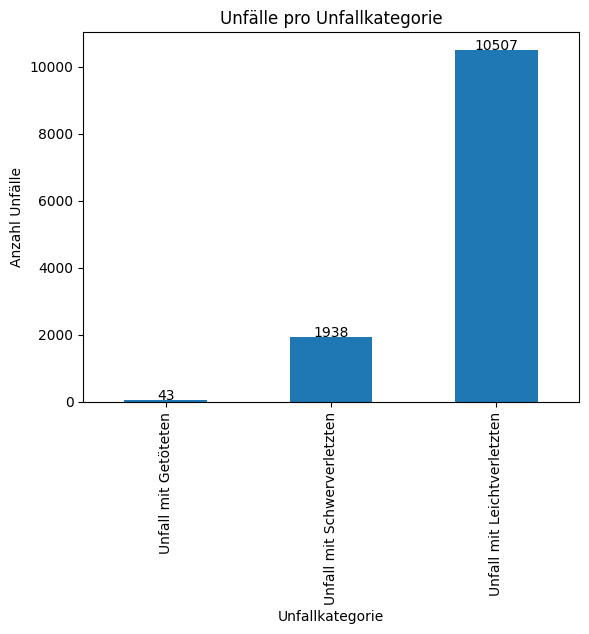

In [22]:
#plot the number of accidents by the category of the accident
unfaelle_category = unfaelle_edit['UKATEGORIE'].value_counts().sort_index()
unfaelle_category['UKATEGORIE'] = pd.Categorical(unfaelle_edit['UKATEGORIE'], categories=category.values(), ordered=True)

unfaelle_category['UKATEGORIE'].value_counts().sort_index().plot(kind='bar')
#plot exact values onto the bar chart
for i, v in enumerate(unfaelle_category['UKATEGORIE'].value_counts().sort_index()):
    plt.text(i, v, str(v), ha='center')
plt.xlabel('Unfallkategorie')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Unfallkategorie')
plt.show()

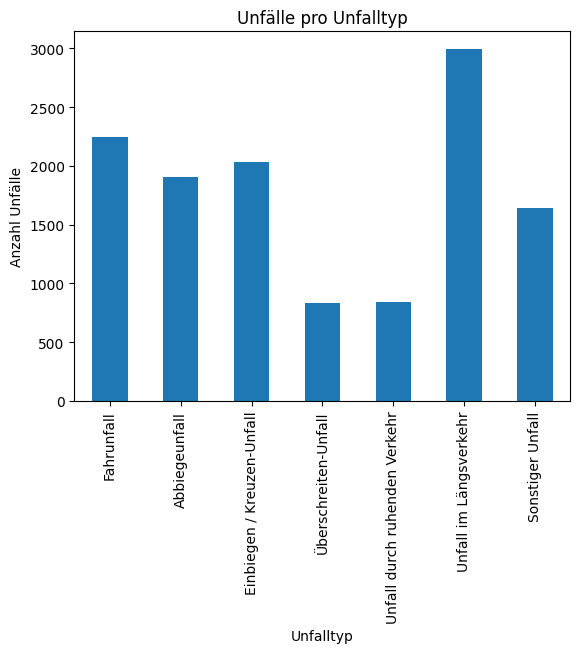

In [23]:
#plot the number of accidents by the type of the accident
unfaelle_type = unfaelle_edit['UTYP1'].value_counts().sort_index()
unfaelle_type['UTYP1'] = pd.Categorical(unfaelle_edit['UTYP1'], categories=type.values(), ordered=True)

unfaelle_type['UTYP1'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Unfalltyp')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Unfalltyp')
plt.show()


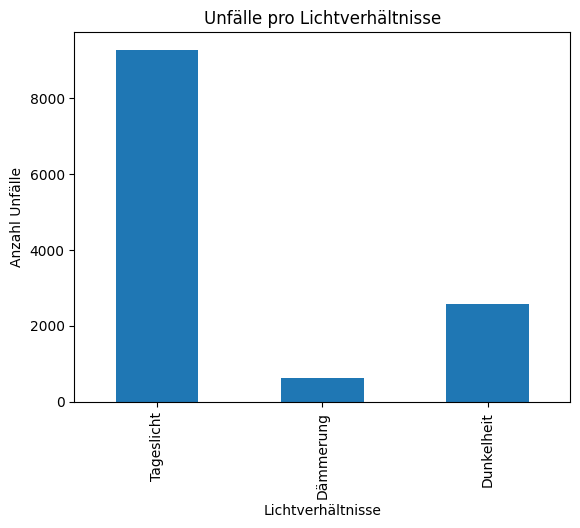

In [24]:
#plot the number of accidents by the light conditions
unfaelle_light = unfaelle_edit['ULICHTVERH'].value_counts().sort_index()
unfaelle_light['ULICHTVERH'] = pd.Categorical(unfaelle_edit['ULICHTVERH'], categories=light.values(), ordered=True)

unfaelle_light['ULICHTVERH'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Lichtverhältnisse')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Lichtverhältnisse')
plt.show()


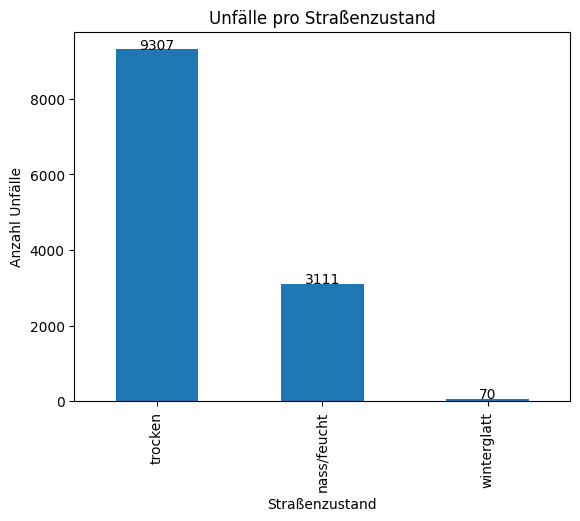

In [25]:
#plot the number of accidents by the road conditions
unfaelle_condition = unfaelle_edit['USTRZUSTAND'].value_counts().sort_index()
unfaelle_condition['USTRZUSTAND'] = pd.Categorical(unfaelle_edit['USTRZUSTAND'], categories=condition.values(), ordered=True)

unfaelle_condition['USTRZUSTAND'].value_counts().sort_index().plot(kind='bar')
#plot the exact values onto the bar chart
for i, v in enumerate(unfaelle_condition['USTRZUSTAND'].value_counts().sort_index()):
    plt.text(i, v, str(v), ha='center')
plt.xlabel('Straßenzustand')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Straßenzustand')
plt.show()

126 Tage Regen im Jahr im Schnitt
Heißt 34% der Tage im Jahr regnet es ca.
Aber hier nur 25% Unfälle bei Regen
Also Regen keinen starken Einfluss auf Unfälle

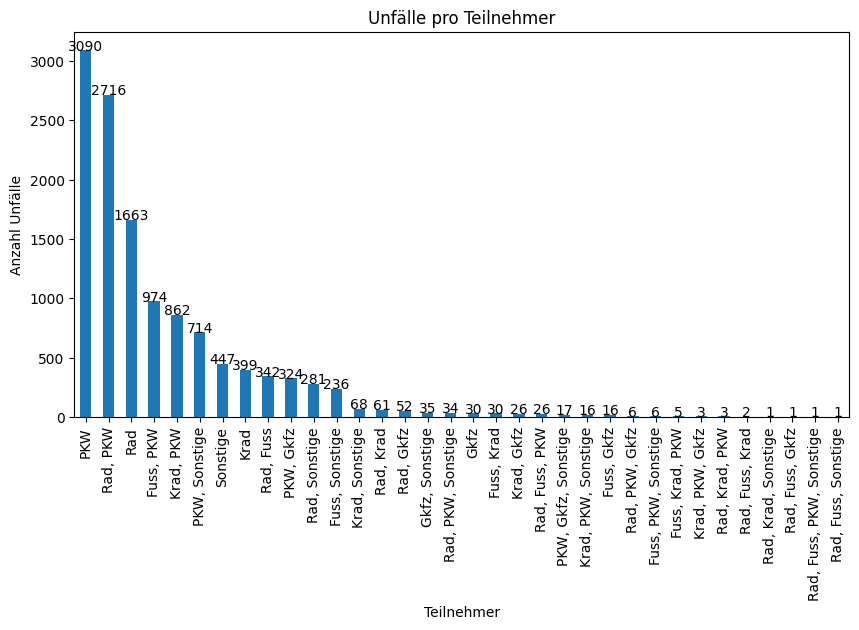

In [26]:
#plot the number of accidents by the participants
unfaelle_participants = unfaelle_edit['Participants'].value_counts().sort_index()
unfaelle_participants['Participants'] = pd.Categorical(unfaelle_edit['Participants'], categories=unfaelle_edit['Participants'].unique())

#sort the values by the amount of accidents


plt.figure(figsize=(10,5))
unfaelle_participants['Participants'].value_counts().sort_values(ascending=False).plot(kind='bar')
#plot the exact values onto the bar chart
for i, v in enumerate(unfaelle_participants['Participants'].value_counts().sort_values(ascending=False)):
    plt.text(i, v, str(v), ha='center')
plt.xlabel('Teilnehmer')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Teilnehmer')
plt.show()


In [27]:
#print the coordinates of the accidents with participants rad fuss sonstige
unfaelle_edit[(unfaelle_edit['IstRad'] == 1) & (unfaelle_edit['IstFuss'] == 1) & (unfaelle_edit['IstSonstige'] == 1)][['XGCSWGS84', 'YGCSWGS84', 'Participants']]

,XGCSWGS84,YGCSWGS84,Participants
8548,6.957106,50.952176,"Rad, Fuss, PKW, Sonstige"
9606,6.896975,50.937170,"Rad, Fuss, Sonstige"


In [28]:
unfaelle_cut = unfaelle.drop(columns=['XGCSWGS84', 'YGCSWGS84', 'OBJECTID', 'IstRad', 
                                                        'IstFuss', 'IstKrad', 'IstPKW', 'IstGkfz', 
                                                        'IstSonstige', 'LINREFX', 'LINREFY', 'UIDENTSTLAE', "UJAHR", "UMONAT", "ULAND", "UGEMEINDE", "UKREIS", "UREGBEZ"])

In [29]:
unfaelle_cut

,USTUNDE,UWOCHENTAG,UKATEGORIE,UART,UTYP1,ULICHTVERH,USTRZUSTAND
0,5,3,3,3,7,2,1
1,4,3,2,9,7,2,1
2,19,3,3,2,6,2,1
3,14,1,2,8,1,0,1
4,19,7,3,2,6,2,1
...,...,...,...,...,...,...,...
12492,3,2,3,1,5,2,0
12493,18,6,3,5,3,0,0
12494,10,4,3,4,7,0,0
12495,7,2,2,5,3,0,0


# Plots von Schwerverletzten und Getöteten

In [30]:
unfaelle_category_schwer = unfaelle_edit[unfaelle_edit['UKATEGORIE'].isin(['Unfall mit Getöteten', 'Unfall mit Schwerverletzten'])]

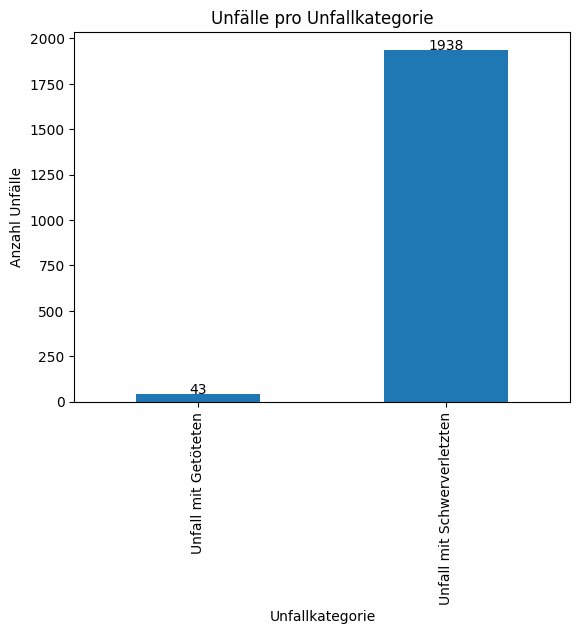

In [31]:
#plot the number of accidents by the category of the accident

unfaelle_category_schwer['UKATEGORIE'].value_counts().sort_index().plot(kind='bar')
#plot exact values onto the bar chart
for i, v in enumerate(unfaelle_category_schwer['UKATEGORIE'].value_counts().sort_index()):
    plt.text(i, v, str(v), ha='center')
plt.xlabel('Unfallkategorie')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Unfallkategorie')
plt.show()

In [32]:
fig = px.scatter_map(unfaelle_category_schwer, lat="YGCSWGS84", lon="XGCSWGS84", hover_name="UART", hover_data=["OBJECTID","UJAHR","UMONAT",
                                                                                                     "UWOCHENTAG","USTUNDE", "UKATEGORIE", "UTYP1", "ULICHTVERH", "USTRZUSTAND", "Participants"],
                        color_discrete_sequence=["red"], zoom=9, height=300, labels=labels)
fig.update_layout(map_style="open-street-map")

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [33]:
# save the data of the accidents with Tote
unfaelle_category_tot = unfaelle_edit[unfaelle_edit['UKATEGORIE'].isin(['Unfall mit Getöteten'])]

In [34]:
fig = px.scatter_map(unfaelle_category_tot, lat="YGCSWGS84", lon="XGCSWGS84", hover_name="UART", hover_data=["OBJECTID","UJAHR","UMONAT",
                                                                                                     "UWOCHENTAG","USTUNDE", "UKATEGORIE", "UTYP1", "ULICHTVERH", "USTRZUSTAND", "Participants"],
                        color_discrete_sequence=["red"], zoom=9, height=300, labels=labels)
fig.update_layout(map_style="open-street-map")

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

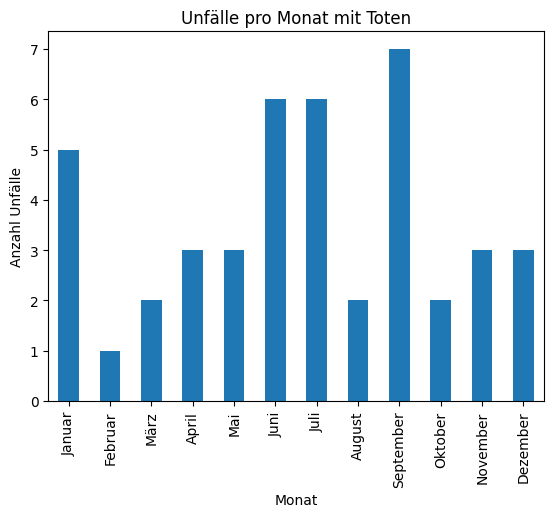

In [35]:
#plot the number of accidents per month with a bar chart in matplotlib sortiert nach monaten
#sort the values by the month
unfaelle_ordered = unfaelle_category_tot['UMONAT'].value_counts().sort_index()
unfaelle_ordered['UMONAT'] = pd.Categorical(unfaelle_category_tot['UMONAT'], categories=months.values(), ordered=True)

import matplotlib.pyplot as plt
unfaelle_ordered['UMONAT'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Monat')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Monat mit Toten')
plt.show()

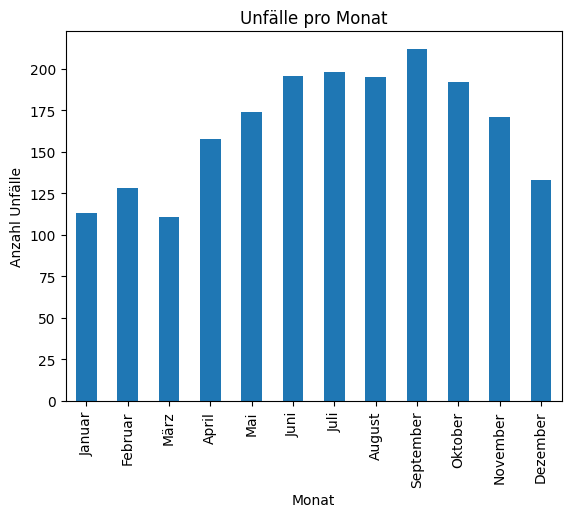

In [36]:
#plot the number of accidents per month with a bar chart in matplotlib sortiert nach monaten
#sort the values by the month
unfaelle_ordered = unfaelle_category_schwer['UMONAT'].value_counts().sort_index()
unfaelle_ordered['UMONAT'] = pd.Categorical(unfaelle_category_schwer['UMONAT'], categories=months.values(), ordered=True)

unfaelle_ordered['UMONAT'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Monat')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Monat')
plt.show()

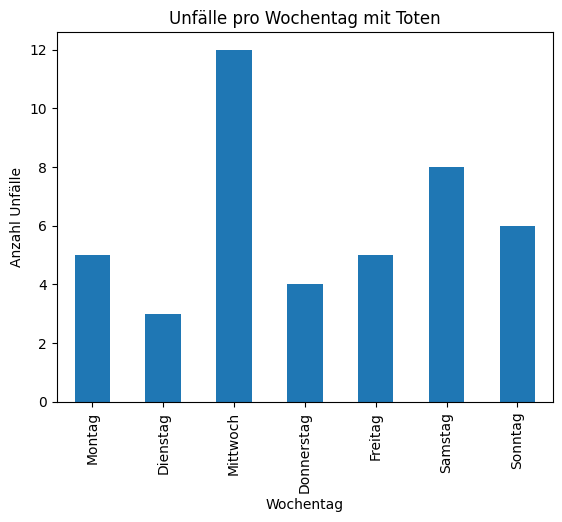

In [37]:
#order by the weekday
unfaelle_ordered['UWOCHENTAG'] = pd.Categorical(unfaelle_category_tot['UWOCHENTAG'], categories=weekday.values(), ordered=True)


unfaelle_ordered['UWOCHENTAG'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Wochentag')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Wochentag mit Toten')
plt.show()

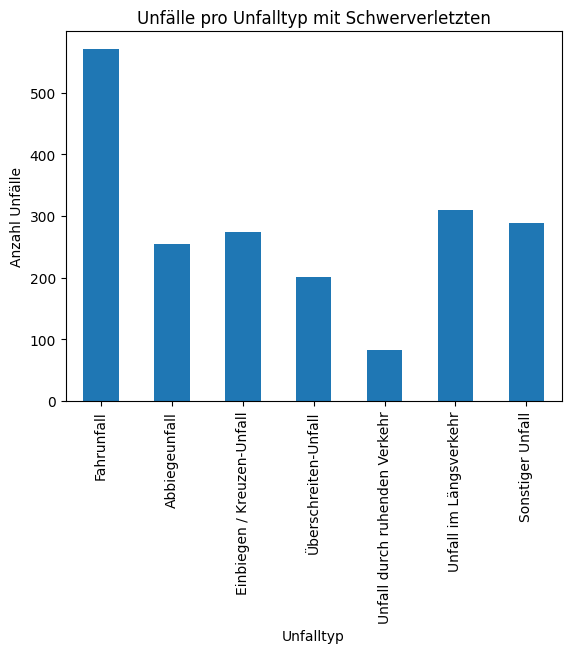

In [38]:
#plot the number of accidents by the type of the accident
unfaelle_type = unfaelle_category_schwer['UTYP1'].value_counts().sort_index()
unfaelle_type['UTYP1'] = pd.Categorical(unfaelle_category_schwer['UTYP1'], categories=type.values(), ordered=True)

unfaelle_type['UTYP1'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Unfalltyp')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Unfalltyp mit Schwerverletzten')
plt.show()

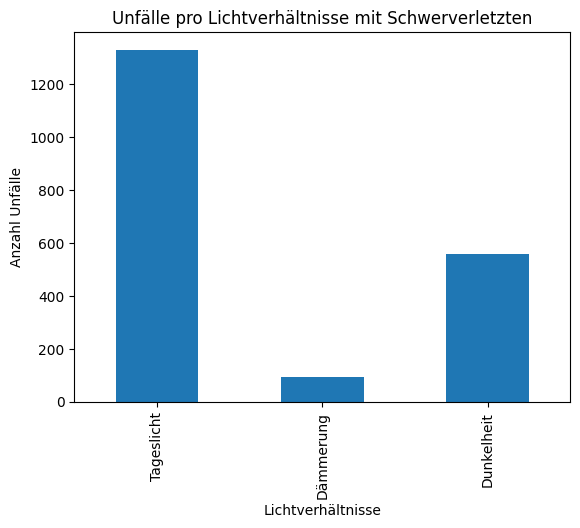

In [39]:
#plot the number of accidents by the light conditions
unfaelle_light = unfaelle_category_schwer['ULICHTVERH'].value_counts().sort_index()
unfaelle_light['ULICHTVERH'] = pd.Categorical(unfaelle_category_schwer['ULICHTVERH'], categories=light.values(), ordered=True)

unfaelle_light['ULICHTVERH'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Lichtverhältnisse')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Lichtverhältnisse mit Schwerverletzten')
plt.show()

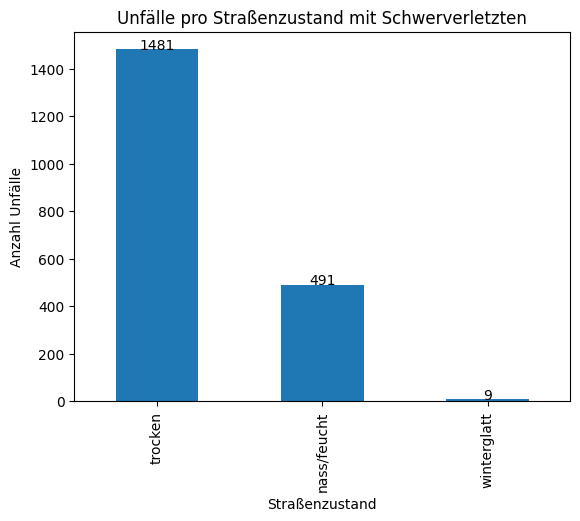

In [40]:
#plot the number of accidents by the road conditions
unfaelle_condition = unfaelle_category_schwer['USTRZUSTAND'].value_counts().sort_index()
unfaelle_condition['USTRZUSTAND'] = pd.Categorical(unfaelle_category_schwer['USTRZUSTAND'], categories=condition.values(), ordered=True)

unfaelle_condition['USTRZUSTAND'].value_counts().sort_index().plot(kind='bar')
#plot the exact values onto the bar chart
for i, v in enumerate(unfaelle_condition['USTRZUSTAND'].value_counts().sort_index()):
    plt.text(i, v, str(v), ha='center')
plt.xlabel('Straßenzustand')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Straßenzustand mit Schwerverletzten')
plt.show()

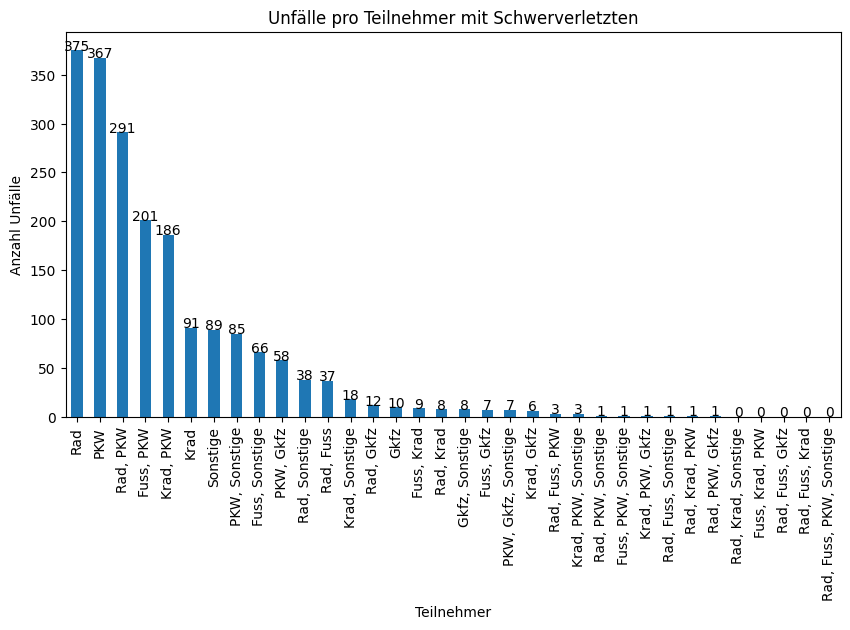

In [41]:
#plot the number of accidents by the participants
unfaelle_participants = unfaelle_category_schwer['Participants'].value_counts().sort_index()
unfaelle_participants['Participants'] = pd.Categorical(unfaelle_category_schwer['Participants'], categories=unfaelle_edit['Participants'].unique())

#sort the values by the amount of accidents


plt.figure(figsize=(10,5))
unfaelle_participants['Participants'].value_counts().sort_values(ascending=False).plot(kind='bar')
#plot the exact values onto the bar chart
for i, v in enumerate(unfaelle_participants['Participants'].value_counts().sort_values(ascending=False)):
    plt.text(i, v, str(v), ha='center')
plt.xlabel('Teilnehmer')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Teilnehmer mit Schwerverletzten')
plt.show()

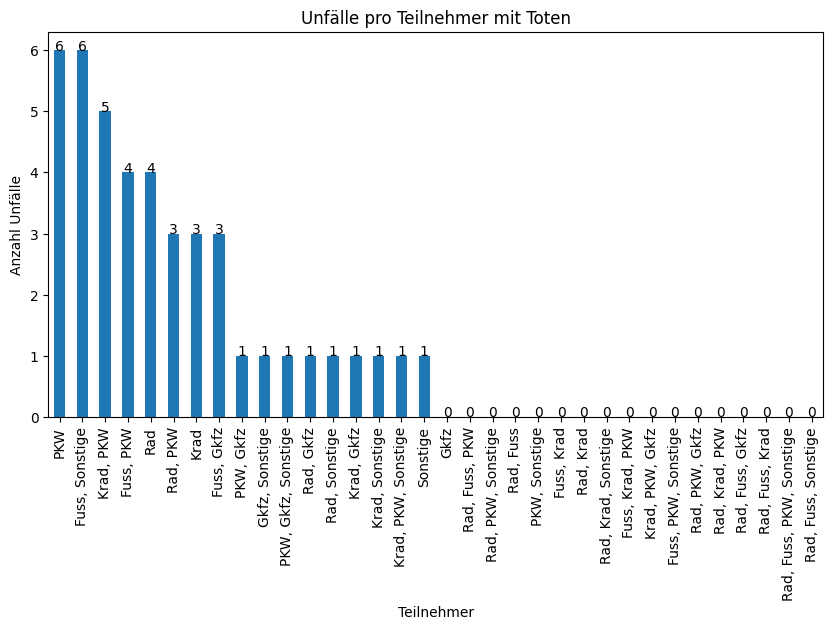

In [42]:
#plot the number of accidents by the participants
unfaelle_participants = unfaelle_category_tot['Participants'].value_counts().sort_index()
unfaelle_participants['Participants'] = pd.Categorical(unfaelle_category_tot['Participants'], categories=unfaelle_edit['Participants'].unique())

#sort the values by the amount of accidents


plt.figure(figsize=(10,5))
unfaelle_participants['Participants'].value_counts().sort_values(ascending=False).plot(kind='bar')
#plot the exact values onto the bar chart
for i, v in enumerate(unfaelle_participants['Participants'].value_counts().sort_values(ascending=False)):
    plt.text(i, v, str(v), ha='center')
plt.xlabel('Teilnehmer')
plt.ylabel('Anzahl Unfälle')
plt.title('Unfälle pro Teilnehmer mit Toten')
plt.show()

In [43]:
#save the unfaelle_edit data
unfaelle_edit.to_csv('unfaelle_edit.csv', index=False)


In [44]:
data = pd.read_csv('unfaelle_edit.csv')	

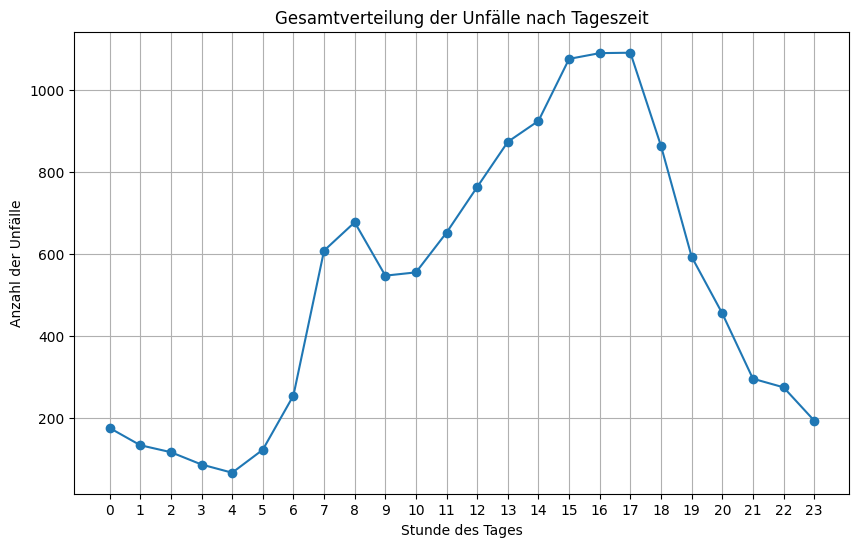

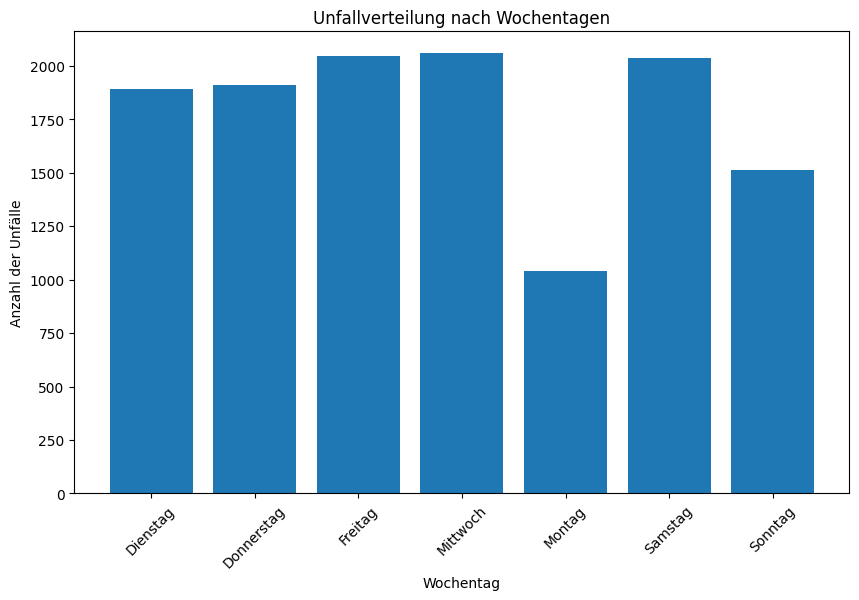

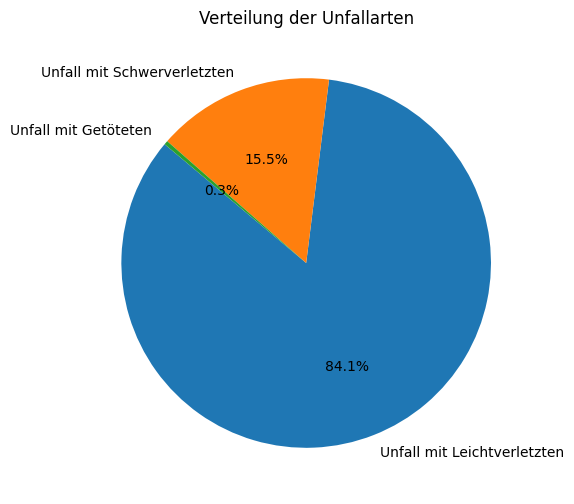

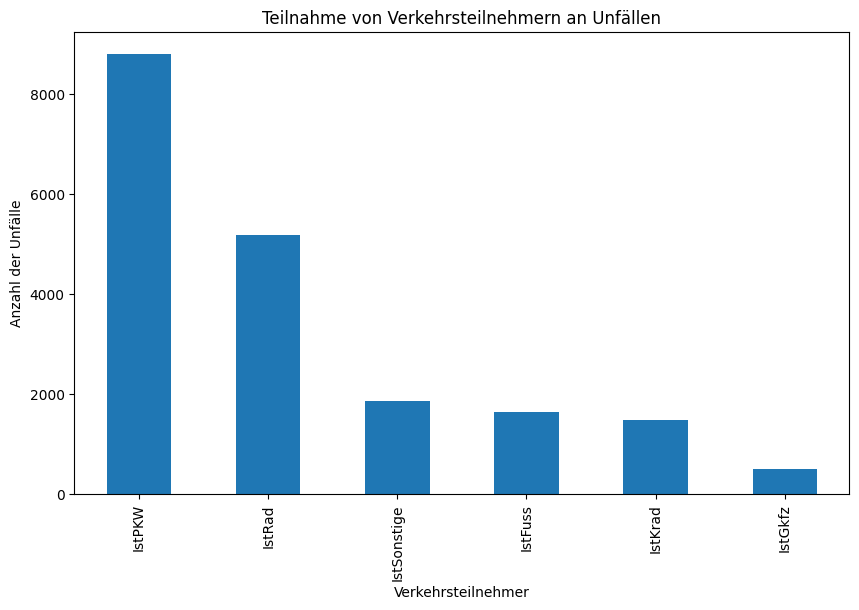

In [45]:
hourly_distribution = data.groupby('USTUNDE').size().reset_index(name='Anzahl_Unfaelle')



plt.figure(figsize=(10, 6))

plt.plot(hourly_distribution['USTUNDE'], hourly_distribution['Anzahl_Unfaelle'], marker='o')

plt.title("Gesamtverteilung der Unfälle nach Tageszeit")

plt.xlabel("Stunde des Tages")

plt.ylabel("Anzahl der Unfälle")

plt.grid(True)

plt.xticks(range(0, 24))

plt.show()



# 2. Unfallverteilung nach Wochentagen

weekday_distribution = data.groupby('UWOCHENTAG').size().reset_index(name='Anzahl_Unfaelle')



plt.figure(figsize=(10, 6))

plt.bar(weekday_distribution['UWOCHENTAG'], weekday_distribution['Anzahl_Unfaelle'])

plt.title("Unfallverteilung nach Wochentagen")

plt.xlabel("Wochentag")

plt.ylabel("Anzahl der Unfälle")

plt.xticks(rotation=45)

plt.show()



# 3. Unfallarten

category_distribution = data['UKATEGORIE'].value_counts()



plt.figure(figsize=(10, 6))

category_distribution.plot(kind='pie', autopct='%1.1f%%', startangle=140)

plt.title("Verteilung der Unfallarten")

plt.ylabel("")

plt.show()



# 4. Teilnahme von Verkehrsteilnehmern

participants = ['IstRad', 'IstPKW', 'IstFuss', 'IstKrad', 'IstGkfz', 'IstSonstige']

participant_counts = data[participants].sum().sort_values(ascending=False)



plt.figure(figsize=(10, 6))

participant_counts.plot(kind='bar')

plt.title("Teilnahme von Verkehrsteilnehmern an Unfällen")

plt.xlabel("Verkehrsteilnehmer")

plt.ylabel("Anzahl der Unfälle")

plt.show()

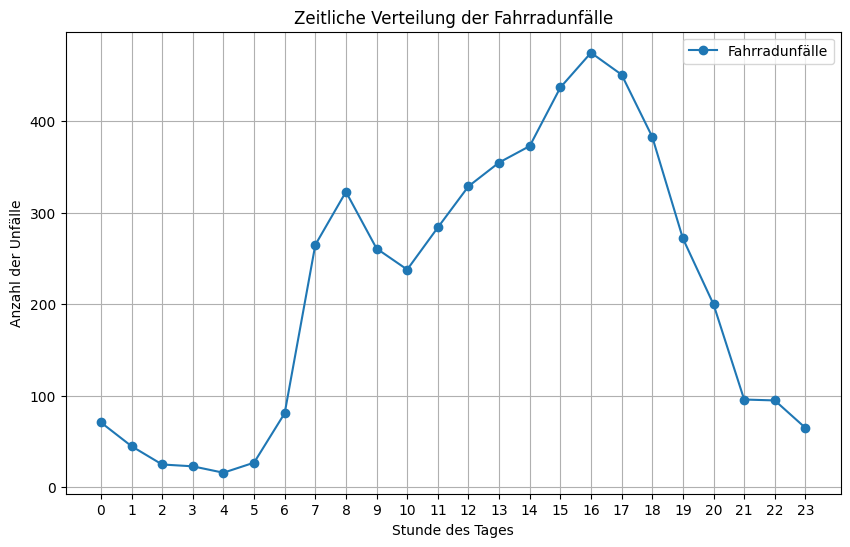

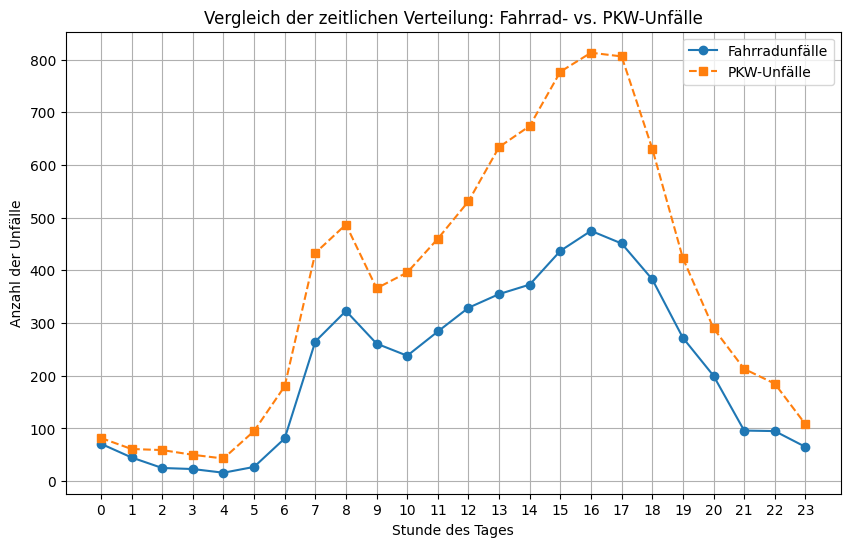

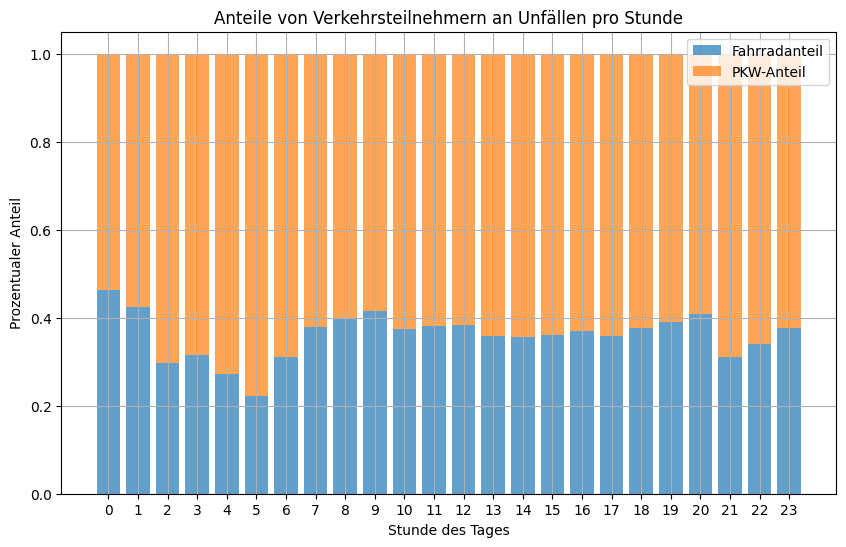

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Laden der Daten

cyclist_data = data[data['IstRad'] == 1]

hourly_cyclist_accidents = cyclist_data.groupby('USTUNDE').size().reset_index(name='Fahrradunfälle')

car_data = data[data['IstPKW'] == 1]

hourly_car_accidents = car_data.groupby('USTUNDE').size().reset_index(name='PKW-Unfälle')

hourly_comparison = pd.merge(hourly_cyclist_accidents, hourly_car_accidents, on='USTUNDE', how='outer').fillna(0)

plt.figure(figsize=(10, 6))
plt.plot(hourly_comparison['USTUNDE'], hourly_comparison['Fahrradunfälle'], marker='o', label='Fahrradunfälle')
plt.title("Zeitliche Verteilung der Fahrradunfälle")
plt.xlabel("Stunde des Tages")
plt.ylabel("Anzahl der Unfälle")
plt.grid(True)
plt.xticks(range(0, 24))
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(hourly_comparison['USTUNDE'], hourly_comparison['Fahrradunfälle'], label='Fahrradunfälle', marker='o')
plt.plot(hourly_comparison['USTUNDE'], hourly_comparison['PKW-Unfälle'], label='PKW-Unfälle', marker='s', linestyle='--')
plt.title("Vergleich der zeitlichen Verteilung: Fahrrad- vs. PKW-Unfälle")
plt.xlabel("Stunde des Tages")
plt.ylabel("Anzahl der Unfälle")
plt.grid(True)
plt.xticks(range(0, 24))
plt.legend()
plt.show()

hourly_comparison['Gesamt'] = hourly_comparison['Fahrradunfälle'] + hourly_comparison['PKW-Unfälle']
hourly_comparison['Fahrradanteil'] = hourly_comparison['Fahrradunfälle'] / hourly_comparison['Gesamt']
hourly_comparison['PKW-Anteil'] = hourly_comparison['PKW-Unfälle'] / hourly_comparison['Gesamt']

plt.figure(figsize=(10, 6))
plt.bar(hourly_comparison['USTUNDE'], hourly_comparison['Fahrradanteil'], label='Fahrradanteil', alpha=0.7)
plt.bar(hourly_comparison['USTUNDE'], hourly_comparison['PKW-Anteil'], bottom=hourly_comparison['Fahrradanteil'], label='PKW-Anteil', alpha=0.7)
plt.title("Anteile von Verkehrsteilnehmern an Unfällen pro Stunde")
plt.xlabel("Stunde des Tages")
plt.ylabel("Prozentualer Anteil")
plt.legend()
plt.grid(True)
plt.xticks(range(0, 24))
plt.show()


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
# Include all accidents to provide both classes for the target variable
data_encoded = data.copy()

# Encode categorical variables for logistic regression
data_encoded['USTRZUSTAND'] = data_encoded['USTRZUSTAND'].astype('category').cat.codes
data_encoded['UWOCHENTAG'] = data_encoded['UWOCHENTAG'].astype('category').cat.codes

# Select features and target (1 = Fahrradunfall, 0 = kein Fahrradunfall)
features = ['USTUNDE', 'USTRZUSTAND', 'UWOCHENTAG']
X = data_encoded[features]
y = data_encoded['IstRad']

# Ensure both classes are present
print(f"Class distribution:\n{y.value_counts()}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic Regression
model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)

# Display the classification report as a Pandas DataFrame for user inspection
classification_report_df = pd.DataFrame(report).transpose()

# Show the classification report as plain text for exporting or local inspection
classification_report_df.reset_index().rename(columns={'index': 'Metric'})


Class distribution:
IstRad
0    7298
1    5190
Name: count, dtype: int64


,Metric,precision,recall,f1-score,support
0,0,0.578834,0.994462,0.731749,2167.000000
1,1,0.500000,0.007595,0.014963,1580.000000
2,accuracy,0.578329,0.578329,0.578329,0.578329
3,macro avg,0.539417,0.501029,0.373356,3747.000000
4,weighted avg,0.545592,0.578329,0.429501,3747.000000


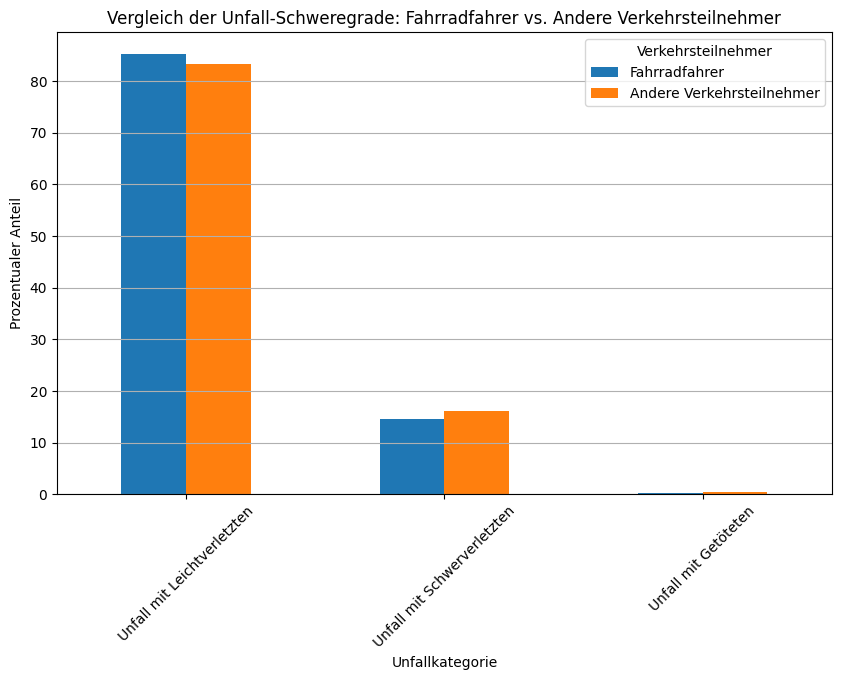

In [48]:
# Analyze the severity of accidents for cyclists and other participants
severity_distribution_cyclists = cyclist_data['UKATEGORIE'].value_counts(normalize=True) * 100
severity_distribution_others = data[data['IstRad'] == 0]['UKATEGORIE'].value_counts(normalize=True) * 100

# Combine both distributions into a single DataFrame for comparison
severity_comparison = pd.DataFrame({
    'Fahrradfahrer': severity_distribution_cyclists,
    'Andere Verkehrsteilnehmer': severity_distribution_others
}).fillna(0)

# Plot the comparison of accident severity
severity_comparison.plot(kind='bar', figsize=(10, 6))
plt.title("Vergleich der Unfall-Schweregrade: Fahrradfahrer vs. Andere Verkehrsteilnehmer")
plt.xlabel("Unfallkategorie")
plt.ylabel("Prozentualer Anteil")
plt.legend(title="Verkehrsteilnehmer")
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.show()


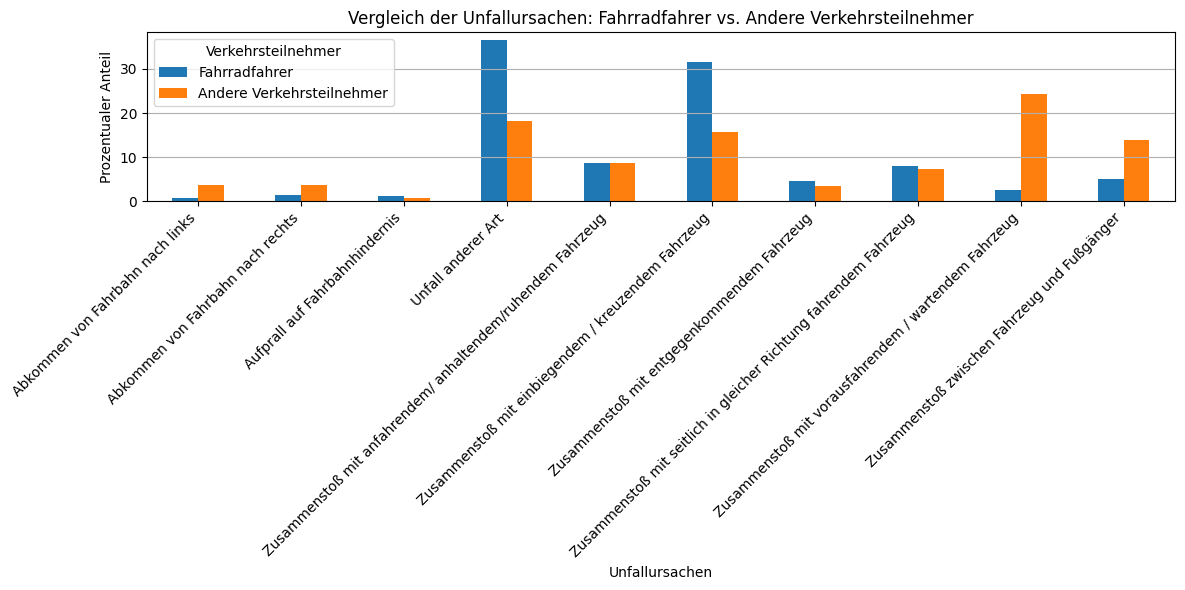

In [49]:
# Analyze the causes of accidents for cyclists and other participants
causes_cyclists = cyclist_data['UART'].value_counts(normalize=True) * 100
causes_others = data[data['IstRad'] == 0]['UART'].value_counts(normalize=True) * 100

# Combine both distributions into a single DataFrame for comparison
causes_comparison = pd.DataFrame({
    'Fahrradfahrer': causes_cyclists,
    'Andere Verkehrsteilnehmer': causes_others
}).fillna(0)

# Plot the comparison of accident causes with corrected labels
fig, ax = plt.subplots(figsize=(12, 6))
causes_comparison.plot(kind='bar', ax=ax)
plt.title("Vergleich der Unfallursachen: Fahrradfahrer vs. Andere Verkehrsteilnehmer")
plt.xlabel("Unfallursachen")
plt.ylabel("Prozentualer Anteil")
plt.legend(title="Verkehrsteilnehmer")
plt.grid(axis='y')

# Correct the X-axis tick positions and labels
ax.set_xticks(range(len(causes_comparison.index)))
ax.set_xticklabels(causes_comparison.index, rotation=45, ha='right')
plt.tight_layout()  # Ensure proper spacing
plt.show()


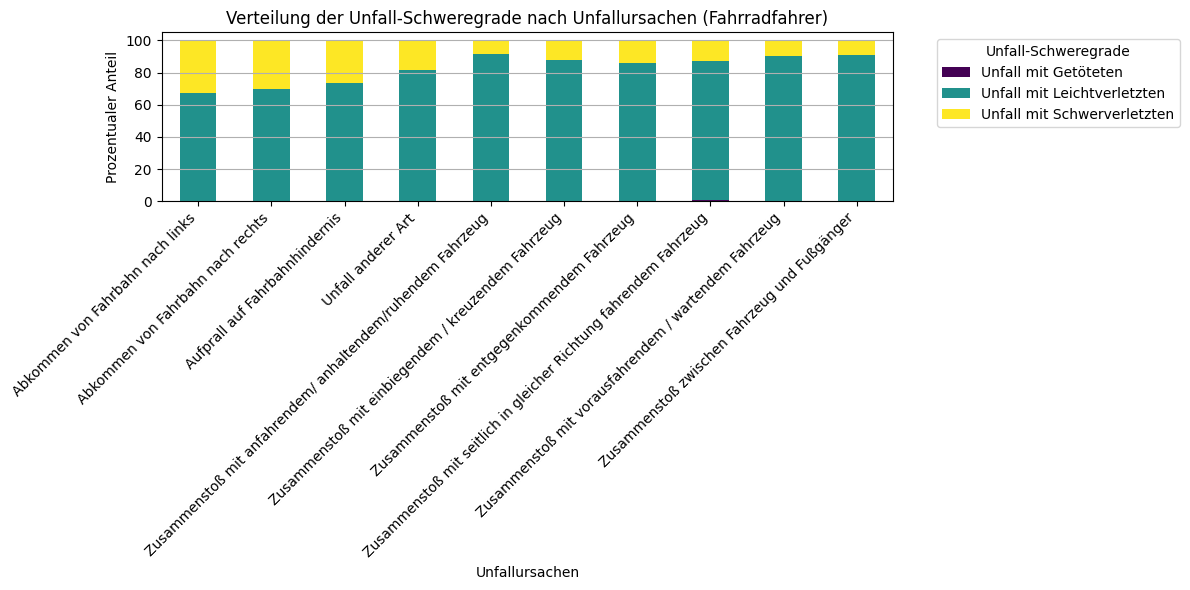

In [50]:
# Analyze severity distribution per accident cause for cyclists
severity_cause_cyclists = cyclist_data.groupby(['UART', 'UKATEGORIE']).size().unstack(fill_value=0)

# Normalize to percentages
severity_cause_cyclists_percentage = severity_cause_cyclists.div(severity_cause_cyclists.sum(axis=1), axis=0) * 100

# Plot the distribution of severities per cause
severity_cause_cyclists_percentage.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title("Verteilung der Unfall-Schweregrade nach Unfallursachen (Fahrradfahrer)")
plt.xlabel("Unfallursachen")
plt.ylabel("Prozentualer Anteil")
plt.legend(title="Unfall-Schweregrade", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [51]:
import pandas as pd
import plotly.graph_objects as go

# Laden der Daten
file_path = 'unfaelle.csv'  # Passe den Pfad zur Datei an
data = pd.read_csv(file_path)

# Filterung der relevanten Spalten und Entfernen von NaNs
accidents = data[['YGCSWGS84', 'XGCSWGS84']].dropna()

# Erstellen der interaktiven Heatmap mit Plotly
fig = go.Figure(go.Densitymapbox(
    lat=accidents['YGCSWGS84'],
    lon=accidents['XGCSWGS84'],
    radius=8,
    colorscale=[
        [0, "yellow"], 
        [0.5, "orange"], 
        [1, "red"]
    ],
    zauto=True
))

# Layout für die Karte mit interaktivem Zoom
fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={"lat": 50.9375, "lon": 6.9603},  # Zentrum von Köln
    mapbox_zoom=13,
    title="Interaktive Heatmap der Unfälle in Köln"
)

# Anzeigen der interaktiven Karte
fig.show()


In [52]:
import pandas as pd
import plotly.graph_objects as go

# Laden der Daten
file_path = 'unfaelle.csv'  # Passe den Pfad zur Datei an
data = pd.read_csv(file_path)

# Filtern der Fahrradunfälle und relevanten Spalten
cyclist_data = data[data['IstRad'] == 1][['YGCSWGS84', 'XGCSWGS84']].dropna()

# Erstellen der Heatmap für Fahrradunfälle
fig = go.Figure(go.Densitymapbox(
    lat=cyclist_data['YGCSWGS84'],
    lon=cyclist_data['XGCSWGS84'],
    radius=8,  # Radius der Punkte, kann angepasst werden
    colorscale=[
        [0, "yellow"], 
        [0.5, "orange"], 
        [1, "red"]
    ],
    zauto=True
))

# Layout für die Karte mit interaktivem Zoom
fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={"lat": 50.9375, "lon": 6.9603},  # Zentrum von Köln
    mapbox_zoom=13,
    title="Heatmap der Fahrradunfälle in Köln"
)

# Anzeigen der Heatmap
fig.show()


In [53]:
import pandas as pd
import plotly.express as px
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler

# Laden der Daten
file_path = 'unfaelle.csv'  # Passe den Pfad zur Datei an
data = pd.read_csv(file_path)

# Filtern der relevanten Spalten für Fahrradfahrer und Entfernen von NaNs
cyclist_data = data[data['IstRad'] == 1][['YGCSWGS84', 'XGCSWGS84']].dropna()

# Daten vorbereiten (Skalieren für k-Means)
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(cyclist_data)

# ------------------------------------------
# DBSCAN-Clusteranalyse
# ------------------------------------------
dbscan = DBSCAN(eps=0.05, min_samples=10)
cyclist_data['DBSCAN_Cluster'] = dbscan.fit_predict(coords_scaled)

# ------------------------------------------
# k-Means-Clusteranalyse
# ------------------------------------------
kmeans = KMeans(n_clusters=20, random_state=42)  # Anzahl der Cluster anpassen
cyclist_data['KMeans_Cluster'] = kmeans.fit_predict(coords_scaled)

# ------------------------------------------
# Visualisierung der Cluster mit Plotly
# ------------------------------------------

# Funktion zur Visualisierung der Cluster
def plot_clusters(cluster_column, title):
    fig = px.scatter_mapbox(
        cyclist_data,
        lat='YGCSWGS84',
        lon='XGCSWGS84',
        color=cluster_column,
        title=title,
        mapbox_style='open-street-map',
        zoom=12,
        hover_data=['YGCSWGS84', 'XGCSWGS84']
    )
    fig.update_traces(marker=dict(size=7))
    fig.show()

# DBSCAN-Visualisierung
plot_clusters('DBSCAN_Cluster', 'DBSCAN-Clusteranalyse der Fahrradunfälle in Köln')

# k-Means-Visualisierung
plot_clusters('KMeans_Cluster', 'k-Means-Clusteranalyse der Fahrradunfälle in Köln')


In [54]:
import pandas as pd
import plotly.express as px
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Laden der Daten
file_path = 'unfaelle.csv'  # Passe den Pfad zur Datei an
data = pd.read_csv(file_path)

# Filtern der relevanten Spalten für Fahrradfahrer und Entfernen von NaNs
cyclist_data = data[data['IstRad'] == 1][['YGCSWGS84', 'XGCSWGS84']].dropna()

# Daten skalieren für DBSCAN
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(cyclist_data)

# DBSCAN-Clusteranalyse
dbscan = DBSCAN(eps=0.05, min_samples=10)
cyclist_data['DBSCAN_Cluster'] = dbscan.fit_predict(coords_scaled)

# Konvertiere Cluster-Labels zu Strings, um unterschiedliche Farben zuweisen zu können
cyclist_data['DBSCAN_Cluster'] = cyclist_data['DBSCAN_Cluster'].astype(str)

# Interaktive Visualisierung der DBSCAN-Cluster mit unterschiedlichen Farben
fig = px.scatter_mapbox(
    cyclist_data,
    lat='YGCSWGS84',
    lon='XGCSWGS84',
    color='DBSCAN_Cluster',
    title='DBSCAN-Clusteranalyse der Fahrradunfälle in Köln',
    mapbox_style='open-street-map',
    zoom=12,
    hover_data=['DBSCAN_Cluster']
)

fig.update_traces(marker=dict(size=7))  # Punkte etwas größer darstellen
fig.show()


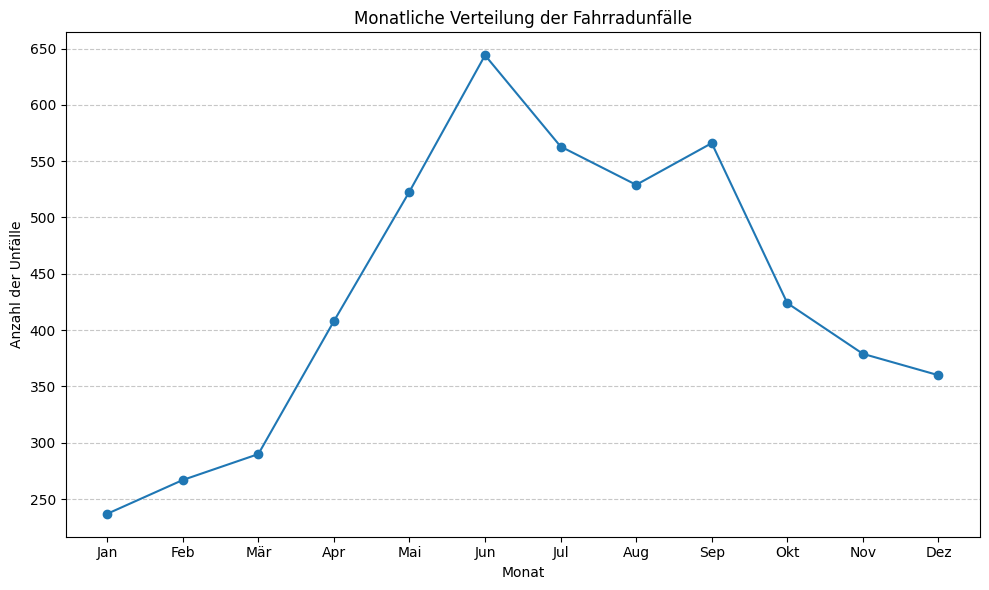

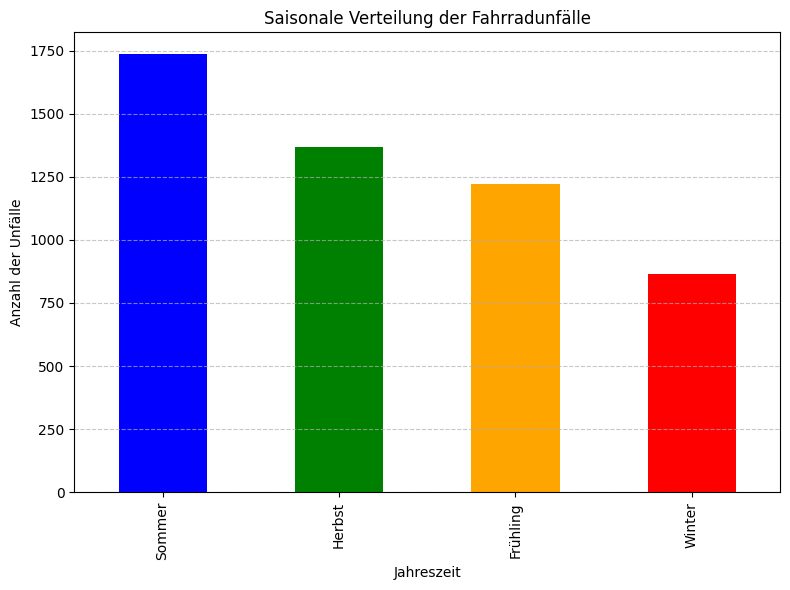

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

if 'UMONAT' not in data.columns:
    raise ValueError("Die Spalte 'UMONAT' fehlt in den Daten. Eine Monats- oder Datumsinformation ist erforderlich.")

cyclist_data = data[data['IstRad'] == 1].copy()

monthly_accidents = cyclist_data['UMONAT'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
monthly_accidents.plot(kind='line', marker='o')
plt.title("Monatliche Verteilung der Fahrradunfälle")
plt.xlabel("Monat")
plt.ylabel("Anzahl der Unfälle")
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

cyclist_data.loc[:, 'Jahreszeit'] = cyclist_data['UMONAT'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Frühling', 4: 'Frühling', 5: 'Frühling',
    6: 'Sommer', 7: 'Sommer', 8: 'Sommer',
    9: 'Herbst', 10: 'Herbst', 11: 'Herbst'
})

seasonal_accidents = cyclist_data['Jahreszeit'].value_counts()

plt.figure(figsize=(8, 6))
seasonal_accidents.plot(kind='bar', color=['blue', 'green', 'orange', 'red'])
plt.title("Saisonale Verteilung der Fahrradunfälle")
plt.xlabel("Jahreszeit")
plt.ylabel("Anzahl der Unfälle")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [69]:
import pandas as pd
import plotly.graph_objects as go

file_path = 'unfaelle.csv' 
data = pd.read_csv(file_path)


heavy_data = data[data['UKATEGORIE'] == 2][['YGCSWGS84', 'XGCSWGS84']].dropna()


fig = go.Figure(go.Densitymapbox(
    lat=heavy_data['YGCSWGS84'],
    lon=heavy_data['XGCSWGS84'],
    radius=8, 
    colorscale=[
        [0, "yellow"], 
        [0.5, "orange"], 
        [1, "red"]
    ],
    zauto=True
))


fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={"lat": 50.9375, "lon": 6.9603}, 
    mapbox_zoom=13,
    title="Heatmap der Schwerverletzten Unfälle in Köln"
)


fig.show()
